Threshold: 0.003877
              precision    recall  f1-score   support

           0       0.89      0.99      0.93     19456
           1       0.78      0.27      0.40      3377

    accuracy                           0.88     22833
   macro avg       0.83      0.63      0.67     22833
weighted avg       0.87      0.88      0.86     22833



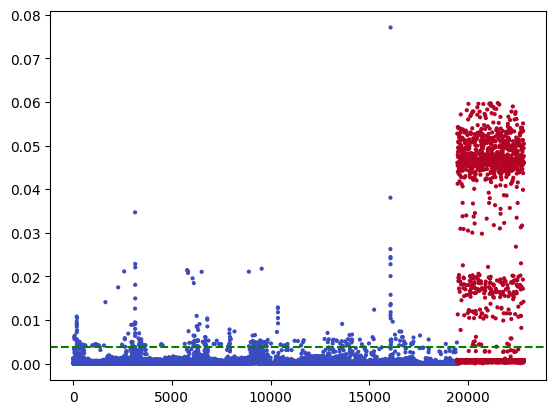

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_kddcup99
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed

# Load & preprocess data
df = fetch_kddcup99(subset='SA', as_frame=True, percent10=True).frame
df['label'] = (df['labels'] != b'normal.').astype(int)

for col in df.select_dtypes(include='object').columns:
    if col != 'labels':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

X = MinMaxScaler().fit_transform(df.drop(columns=['labels','label']))
y = df['label'].values

# Train-test split
X_train = X[y==0][:int(sum(y==0)*0.8)]
X_test  = np.vstack([X[y==0][int(sum(y==0)*0.8):], X[y==1]])
y_test  = np.array([0]*len(X[y==0][int(sum(y==0)*0.8):]) + [1]*len(X[y==1]))

# Reshape
F = X.shape[1]
X_train, X_test = X_train.reshape(-1,1,F), X_test.reshape(-1,1,F)

# Model
inp = Input(shape=(1,F))
x = LSTM(32, activation='relu')(inp)
x = RepeatVector(1)(x)
x = LSTM(32, activation='relu', return_sequences=True)(x)
out = TimeDistributed(Dense(F))(x)

model = Model(inp, out)
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, X_train, epochs=10, batch_size=256, verbose=0)

# Detect anomalies
train_err = np.mean((X_train - model.predict(X_train, verbose=0))**2, axis=(1,2))
test_err  = np.mean((X_test  - model.predict(X_test,  verbose=0))**2, axis=(1,2))

th = train_err.mean() + 3*train_err.std()
y_pred = (test_err > th).astype(int)

print("Threshold:", round(th,6))
print(classification_report(y_test, y_pred))

# Plot
plt.scatter(range(len(test_err)), test_err, c=y_test, cmap='coolwarm', s=4)
plt.axhline(th, color='green', linestyle='--')
plt.show()